#### Init Lib

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.python.summary.summary_iterator import summary_iterator

def generate_dummy(size=100):
    x = list(range(size))
    y = np.random.randint(0, 100, size)
    return x, y

#### Read data from fevent

In [31]:
# reading data from tensorboard logs
import os
from tensorflow.python.summary.summary_iterator import summary_iterator


def load_result(file):
    
    inference_accuracies_no_tfed = {i: [] for i in range(10)}
    transfer = {i: [] for i in range(10)}
    for client in range(10):
        for event in summary_iterator(file):
            for value in event.summary.value:
                if value.HasField("simple_value"):  # Filter for scalar values
                    if value.tag.startswith(f"Client_{client}/InferenceAccuracy"):
                        inference_accuracies_no_tfed[client].append(value.simple_value)
                    if value.tag.startswith(f"Client_{client}/Status"):
                        transfer[client].append(value.simple_value)
    return inference_accuracies_no_tfed, transfer

file_notfed = os.path.join(
    "./results",
    "10_clients_False_tfed_2026-03-31-14-47-44",
    "events.out.tfevents.1774936064.Myoo-00.2375150.0",
)

inference_accuracies_notfed, transfer_notfed = load_result(file_notfed)

file_tfed = os.path.join(
    "./results",
    "10_clients_True_tfed_2026-03-31-15-48-53",
    "events.out.tfevents.1774939733.wifi.136178.0",
)
inference_accuracies_tfed, transfer_tfed = load_result(file_tfed)

#### Draw

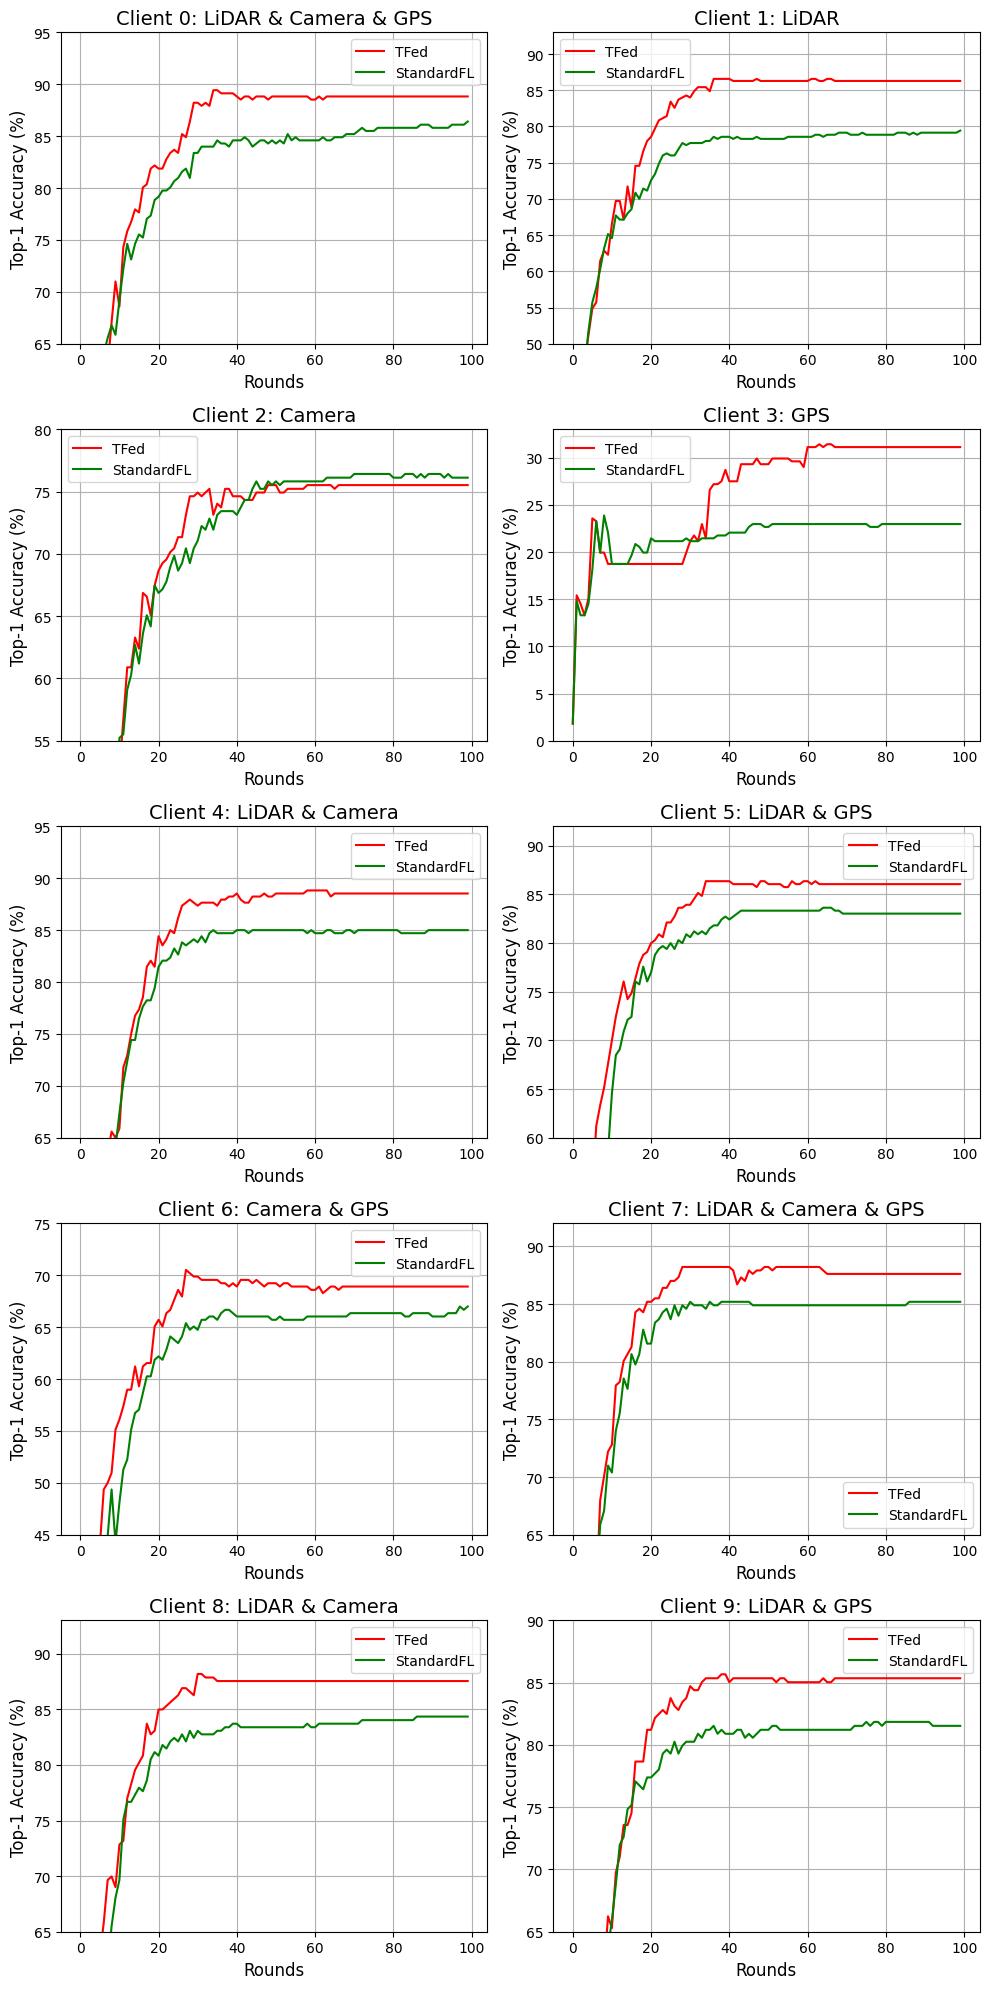

In [32]:
client_name = [
    "Client 0: LiDAR & Camera & GPS",
    "Client 1: LiDAR",
    "Client 2: Camera",
    "Client 3: GPS",
    "Client 4: LiDAR & Camera",
    "Client 5: LiDAR & GPS",
    "Client 6: Camera & GPS",
    "Client 7: LiDAR & Camera & GPS",
    "Client 8: LiDAR & Camera",
    "Client 9: LiDAR & GPS",
]

y_lim = {
    0: (65, 95),
    1: (50, 93),
    2: (55, 80),
    3: (0, 33),
    4: (65, 95),
    5: (60, 92),
    6: (45, 75),
    7: (65, 92),
    8: (65, 93),
    9: (65, 90),
}

# create sub-plots 5 row 2 column
fig, axs = plt.subplots(5, 2, figsize=(10, 20))

for i in range(5):
    for j in range(2):
        axs[i, j].plot(list(range(100)), inference_accuracies_tfed[i * 2 + j], color="red")
        axs[i, j].plot(list(range(100)), inference_accuracies_notfed[i * 2 + j], color="green")
        axs[i, j].set_title(client_name[i * 2 + j], fontsize=14)
        axs[i, j].set_xlabel("Rounds", fontsize=12)
        axs[i, j].set_ylabel("Top-1 Accuracy (%)", fontsize=12)
        axs[i, j].grid(True)
        axs[i, j].legend(["TFed", "StandardFL"], fontsize=10)
        axs[i, j].set_ylim(y_lim[i * 2 + j])
        axs[i, j].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: int(x)))

plt.tight_layout()
plt.savefig("Accuracy.pdf", dpi=300)
plt.show()


In [33]:
inference_accuracies_tfed[7]

[2.4169185161590576,
 27.190332412719727,
 35.95166015625,
 44.4108772277832,
 49.848941802978516,
 57.70392608642578,
 59.818729400634766,
 67.975830078125,
 70.09063720703125,
 72.20543670654297,
 72.8096694946289,
 77.94561767578125,
 78.24773406982422,
 80.0604248046875,
 80.6646499633789,
 81.26888275146484,
 84.29003143310547,
 84.59214782714844,
 84.29003143310547,
 85.19637298583984,
 85.19637298583984,
 85.49848937988281,
 85.49848937988281,
 86.40483093261719,
 86.40483093261719,
 87.00906372070312,
 87.00906372070312,
 87.3111801147461,
 88.21752166748047,
 88.21752166748047,
 88.21752166748047,
 88.21752166748047,
 88.21752166748047,
 88.21752166748047,
 88.21752166748047,
 88.21752166748047,
 88.21752166748047,
 88.21752166748047,
 88.21752166748047,
 88.21752166748047,
 88.21752166748047,
 87.9154052734375,
 86.70694732666016,
 87.3111801147461,
 87.00906372070312,
 87.9154052734375,
 87.61329650878906,
 87.9154052734375,
 87.9154052734375,
 88.21752166748047,
 88.2175216

In [34]:
3.4 * 1e6 * 16 / 8 / (1024 * 1024)

6.4849853515625

In [35]:
prediction_head = (8256 * 15) / 8 / (1024 * 1024)
full_model_mask = [
            3.4 * 1e6 / 8 / (1024 * 1024) for x in [3.4, 2.2, 2.5, 2.0, 3.1, 2.6, 2.9, 2.4, 2.1, 1.9]
        ]
full_model = [
            x * 1e6 * 15 / 8 / (1024 * 1024) for x in [3.4, 2.2, 2.5, 2.0, 3.1, 2.6, 2.9, 2.4, 2.1, 1.9]
        ]
delta = 16 / 8 / (1024 * 1024) 

In [36]:
over_head_tfed = {i: [] for i in range(10)}
for client in range(10):
    temp = []
    for idx, item in enumerate(transfer_tfed[client]):
        if client == 7:
            if idx > 60:
                item = 1
        if item == 0:
            temp.append(full_model[client] + full_model_mask[client] + delta)
        else:
            temp.append(full_model_mask[client] + prediction_head + delta)
    over_head_tfed[client] = temp

# over_head_notfed = {i: [full_model[i]] * len(range(100)) for i in range(10)}
over_head_notfed = {i: [6.4849853515625] * len(range(100)) for i in range(10)}

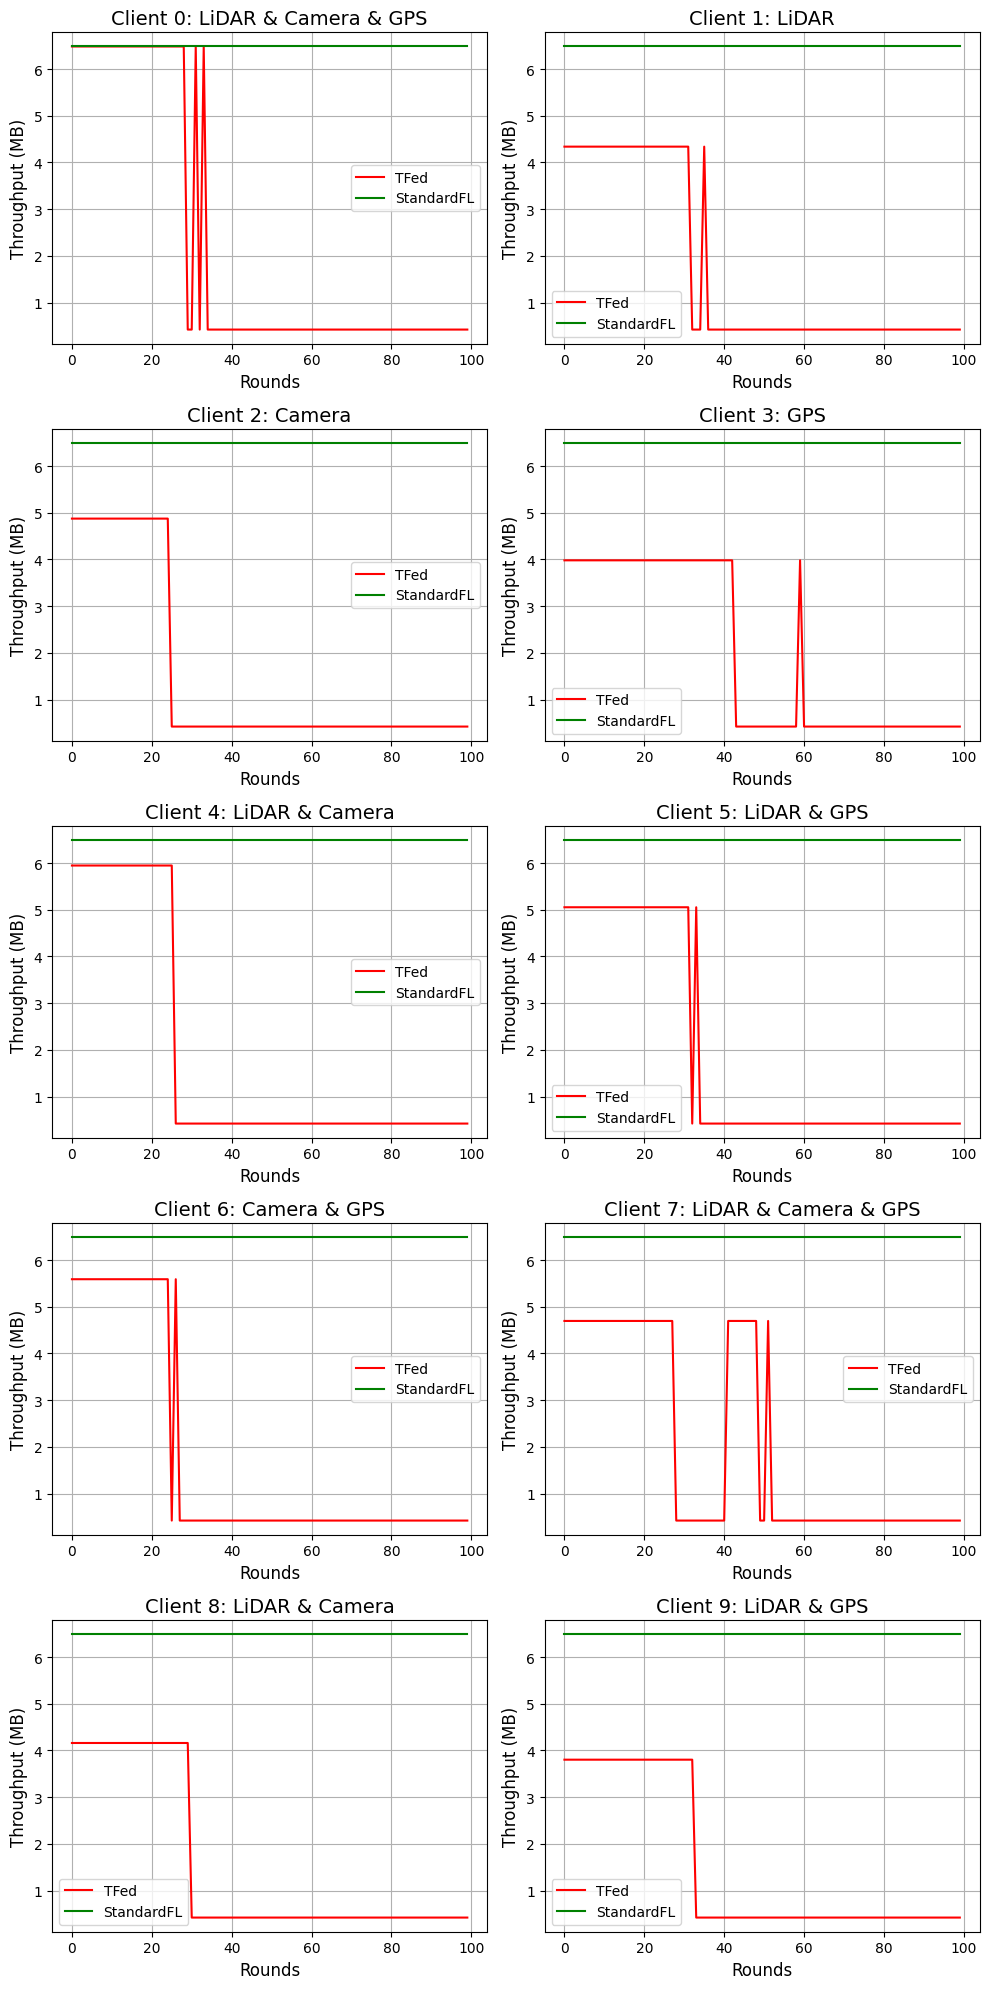

In [37]:
# create sub-plots 5 row 2 column
fig, axs = plt.subplots(5, 2, figsize=(10, 20))

for i in range(5):
    for j in range(2):
        axs[i, j].plot(list(range(100)), over_head_tfed[i * 2 + j], color="red")
        axs[i, j].plot(list(range(100)), over_head_notfed[i * 2 + j], color="green")
        axs[i, j].set_title(client_name[i * 2 + j], fontsize=14)
        axs[i, j].set_xlabel("Rounds", fontsize=12)
        axs[i, j].set_ylabel("Throughput (MB)", fontsize=12)
        axs[i, j].grid(True)
        axs[i, j].legend(["TFed", "StandardFL"], fontsize=10)
        # axs[i, j].set_ylim(y_lim[i * 2 + j])
        axs[i, j].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: int(x)))

plt.tight_layout()
plt.savefig("Communication.pdf", dpi=300)
plt.show()

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.python.summary.summary_iterator import summary_iterator
import regex

scaling_path = os.path.join(
    "./results",
    "scaling")

def measure_round_to_99(file):
    inference_accuracies = {i: [] for i in range(10)}
    for client in range(10):
        # if client == 3:
        #     continue
        for event in summary_iterator(file):
            for value in event.summary.value:
                if value.HasField("simple_value"):  # Filter for scalar values
                    if value.tag.startswith(f"Client_{client}/InferenceAccuracy"):
                        inference_accuracies[client].append(value.simple_value)
    results = {}
    for client in range(10):
        try:
            final_acc = inference_accuracies[client][-1]
            print(f"Client {client}: Final Accuracy = {final_acc}")
            for idx, acc in enumerate(inference_accuracies[client]):
                if acc >= 0.95 * final_acc:
                    results[client] = idx
                    break
        except Exception as e:
            pass
    print(np.mean(list(results.values())))
    print(results)

client = 10
use_tfed = False
file = None

for filename in os.listdir(scaling_path):
    if filename.find(f"{client}_clients") != -1 and filename.find(str(use_tfed)) != -1:
        dir = os.path.join(scaling_path, filename)
        file = os.path.join(dir, os.listdir(dir)[0])

measure_round_to_99(file)

Client 0: Final Accuracy = 86.40483093261719
Client 1: Final Accuracy = 79.42857360839844
Client 2: Final Accuracy = 76.1194076538086
Client 3: Final Accuracy = 22.960725784301758
Client 4: Final Accuracy = 85.00000762939453
Client 5: Final Accuracy = 83.03030395507812
Client 6: Final Accuracy = 66.9871826171875
Client 7: Final Accuracy = 85.19637298583984
Client 8: Final Accuracy = 84.34504699707031
Client 9: Final Accuracy = 81.5286636352539
21.3
{0: 29, 1: 23, 2: 33, 3: 6, 4: 20, 5: 22, 6: 23, 7: 18, 8: 18, 9: 21}
